# E017 — Audio GMM Supervector + Linear SVM

Instead of LLR scoring (log P(x|adapted) − log P(x|UBM)), we extract a
per-utterance **deviation supervector** = (adapted.means_ − ubm.means_).flatten()
and train a **LinearSVC** on these vectors.

Hypothesis: discriminative training on the full 1248-dim supervector space
finds a better boundary than the scalar LLR used in E008.

Baseline comparison: E008 +All → EER = 3.47 / 8.33 / 0.83, mean 4.21 ± 3.11%

In [1]:
from pathlib import Path
import sys, copy
sys.path.insert(0, str(Path("../src").resolve()))

import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from scipy.special import logsumexp
from scipy.stats import norm as scipy_norm
import pandas as pd

from data.splits import load_manifest, iter_folds_loso
from eval.metrics import compute_eer, compute_min_dcf

COLORS = {
    "target":    "#E74C3C",
    "nontarget": "#2E86AB",
    "green":     "#27AE60",
    "purple":    "#8E44AD",
    "gray":      "#95A5A6",
    "orange":    "#E67E22",
}
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

DATA = Path("../data").resolve()
manifest = load_manifest(DATA)
y_all = manifest["label"].to_numpy()
SEED = 67
print(f"{len(manifest)} samples — {manifest.label.sum()} target, {(manifest.label==0).sum()} non-target")

222 samples — 30 target, 192 non-target


## 1. Feature extraction and augmentation functions (same as E008)

In [2]:
def find_wav(stem: str, data_dir: Path) -> Path:
    for sf in ["target_train", "target_dev", "non_target_train", "non_target_dev"]:
        p = data_dir / sf / (stem + ".wav")
        if p.exists():
            return p
    raise FileNotFoundError(stem)


def aug_noise(y: np.ndarray, snr_db: float = 20.0, rng=None) -> np.ndarray:
    signal_power = np.mean(y ** 2) + 1e-10
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise = rng.normal(0, np.sqrt(noise_power), len(y)).astype(y.dtype)
    return y + noise


def aug_speed(y: np.ndarray, rate_range=(0.9, 1.1), rng=None) -> np.ndarray:
    rate = rng.uniform(*rate_range)
    return librosa.effects.time_stretch(y, rate=rate)


def extract_mfcc(y: np.ndarray, sr: int, n_mfcc: int = 13) -> np.ndarray:
    """MFCC + delta + delta-delta + CMN. Returns (T, 39)."""
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    mfcc   = np.vstack([mfcc, delta, delta2]).T
    mfcc  -= mfcc.mean(axis=0)  # CMN
    return mfcc


def load_and_augment(wav_path: Path, rng):
    """Load WAV and return list of (y, sr) — original + noisy + speed-perturbed (+All)."""
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    return [
        (y, sr),
        (aug_noise(y, snr_db=20.0, rng=rng), sr),
        (aug_speed(y, rng=rng), sr),
    ]


print("Feature functions defined.")

Feature functions defined.


## 2. UBM training and MAP adaptation

In [3]:
def train_ubm(X: np.ndarray, n_components: int = 32, seed: int = 67) -> GaussianMixture:
    return GaussianMixture(
        n_components=n_components, covariance_type="diag",
        max_iter=200, random_state=seed,
    ).fit(X)


def map_adapt(ubm: GaussianMixture, X_utt: np.ndarray, r: float = 16.0) -> GaussianMixture:
    """MAP-adapt UBM means using frames from a single utterance."""
    log_prob  = ubm._estimate_log_prob(X_utt)
    log_resp  = log_prob + np.log(ubm.weights_)
    log_resp -= logsumexp(log_resp, axis=1, keepdims=True)
    resp      = np.exp(log_resp)
    n_k       = resp.sum(axis=0)
    mu_hat    = (resp.T @ X_utt) / (n_k[:, None] + 1e-10)
    alpha     = n_k / (n_k + r)
    adapted   = copy.deepcopy(ubm)
    adapted.means_ = alpha[:, None] * mu_hat + (1 - alpha[:, None]) * ubm.means_
    return adapted


def utterance_supervector(wav_path: Path, ubm: GaussianMixture, r: float = 16.0) -> np.ndarray:
    """Load WAV, MAP-adapt UBM, return deviation supervector shape (n_components*39,)."""
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    mfcc = extract_mfcc(y, sr)
    adapted = map_adapt(ubm, mfcc, r=r)
    return (adapted.means_ - ubm.means_).flatten()


def utterance_supervector_from_mfcc(mfcc: np.ndarray, ubm: GaussianMixture, r: float = 16.0) -> np.ndarray:
    """Compute supervector from pre-extracted MFCC frames."""
    adapted = map_adapt(ubm, mfcc, r=r)
    return (adapted.means_ - ubm.means_).flatten()


print("UBM+MAP+supervector functions defined.")

UBM+MAP+supervector functions defined.


## 3. LOSO cross-validation — GMM-SVM

For each fold:
1. Extract non-target frames from train fold (+ Aug +All) → train UBM
2. For each train utterance (original + 2 augmented versions) → MAP-adapt UBM → deviation supervector
3. Stack supervectors → StandardScaler → LinearSVC
4. For each val utterance (original only) → supervector → SVM.decision_function() → score

In [4]:
UBM_COMPONENTS = 32
MAP_R = 16.0
SVM_C = 1.0

oof_scores = np.full(len(manifest), np.nan)
fold_results = []

for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
    print(f"\n{'='*55}")
    print(f"Fold {fold_id}")
    print('='*55)

    train_df = manifest.loc[train_idx]
    val_df   = manifest.loc[val_idx]
    rng = np.random.default_rng(SEED + fold_id)

    # --- Step 1: collect non-target frames (augmented) to train UBM ---
    nt_frames = []
    for _, row in train_df[train_df.label == 0].iterrows():
        wav_path = find_wav(row["stem"], DATA)
        for y_aug, sr in load_and_augment(wav_path, rng):
            nt_frames.append(extract_mfcc(y_aug, sr))
    X_nt = np.vstack(nt_frames)
    print(f"  Non-target frames (aug): {len(X_nt)}")

    ubm = train_ubm(X_nt, n_components=UBM_COMPONENTS, seed=SEED)
    print(f"  UBM trained ({UBM_COMPONENTS} components)")

    # --- Step 2: build supervectors for all train utterances (augmented) ---
    sv_list, label_list = [], []
    rng2 = np.random.default_rng(SEED + fold_id)  # reset rng for reproducibility
    for _, row in train_df.iterrows():
        wav_path = find_wav(row["stem"], DATA)
        for y_aug, sr in load_and_augment(wav_path, rng2):
            mfcc = extract_mfcc(y_aug, sr)
            sv = utterance_supervector_from_mfcc(mfcc, ubm, r=MAP_R)
            sv_list.append(sv)
            label_list.append(row["label"])

    X_sv = np.array(sv_list)
    y_sv = np.array(label_list)
    print(f"  Train supervectors: {X_sv.shape}  (target: {y_sv.sum()}, non-target: {(y_sv==0).sum()})")

    # --- Step 3: fit scaler + SVM ---
    scaler = StandardScaler().fit(X_sv)
    X_sv_sc = scaler.transform(X_sv)
    svm = LinearSVC(C=SVM_C, max_iter=5000, random_state=SEED)
    svm.fit(X_sv_sc, y_sv)
    print(f"  SVM trained (C={SVM_C})")

    # --- Step 4: score val utterances (original only) ---
    for idx, row in val_df.iterrows():
        sv_val = utterance_supervector(find_wav(row["stem"], DATA), ubm, r=MAP_R)
        oof_scores[idx] = svm.decision_function(scaler.transform(sv_val.reshape(1, -1)))[0]

    val_scores = oof_scores[val_idx]
    val_labels = manifest.loc[val_idx, "label"].to_numpy()
    eer, _     = compute_eer(val_scores[val_labels == 1], val_scores[val_labels == 0])
    min_dcf, _ = compute_min_dcf(val_scores[val_labels == 1], val_scores[val_labels == 0])
    fold_results.append({"fold": fold_id, "eer": eer, "min_dcf": min_dcf})
    print(f"  → EER={eer*100:.2f}%, min-DCF={min_dcf:.4f}")

print("\nAll folds done.")


Fold 0


  Non-target frames (aug): 170970


  UBM trained (32 components)


  Train supervectors: (420, 1248)  (target: 60, non-target: 360)
  SVM trained (C=1.0)


  → EER=1.39%, min-DCF=0.0278

Fold 1


...

  → EER=6.67%, min-DCF=0.1333

Fold 2


  Non-target frames (aug): 188277


  UBM trained (32 components)


  Train supervectors: (456, 1248)  (target: 60, non-target: 396)
  SVM trained (C=1.0)


  → EER=19.17%, min-DCF=0.2500

All folds done.


## 4. Results table

In [5]:
eers   = [r["eer"] * 100 for r in fold_results]
dcfs   = [r["min_dcf"]   for r in fold_results]
mean_e = np.mean(eers)
std_e  = np.std(eers)
mean_d = np.mean(dcfs)

# E008 reference
E008 = {"f0": 3.47, "f1": 8.33, "f2": 0.83, "mean": 4.21, "std": 3.11, "dcf": 0.0509}

print(f"{'Config':<22} {'F0 EER':>8} {'F1 EER':>8} {'F2 EER':>8} {'Mean':>8} {'Std':>8} {'min-DCF':>9}")
print("-" * 75)
print(f"{'E008 +All (LLR)':<22} {E008['f0']:>8.2f} {E008['f1']:>8.2f} {E008['f2']:>8.2f} "
      f"{E008['mean']:>8.2f} {E008['std']:>8.2f} {E008['dcf']:>9.4f}")
print(f"{'E017 GMM-SVM':<22} {eers[0]:>8.2f} {eers[1]:>8.2f} {eers[2]:>8.2f} "
      f"{mean_e:>8.2f} {std_e:>8.2f} {mean_d:>9.4f}")
print("-" * 75)

delta = mean_e - E008["mean"]
sign  = "+" if delta >= 0 else ""
print(f"\nDelta vs E008: {sign}{delta:.2f}%")

# OOF overall
valid = ~np.isnan(oof_scores)
eer_oof, _   = compute_eer(oof_scores[valid & (y_all == 1)], oof_scores[valid & (y_all == 0)])
dcf_oof, thr = compute_min_dcf(oof_scores[valid & (y_all == 1)], oof_scores[valid & (y_all == 0)])
print(f"OOF overall: EER={eer_oof*100:.2f}%, min-DCF={dcf_oof:.4f}, threshold={thr:.3f}")

Config                   F0 EER   F1 EER   F2 EER     Mean      Std   min-DCF
---------------------------------------------------------------------------
E008 +All (LLR)            3.47     8.33     0.83     4.21     3.11    0.0509
E017 GMM-SVM               1.39     6.67    19.17     9.07     7.45    0.1370
---------------------------------------------------------------------------

Delta vs E008: +4.86%
OOF overall: EER=9.95%, min-DCF=0.1521, threshold=0.693


## 5. Visualizations

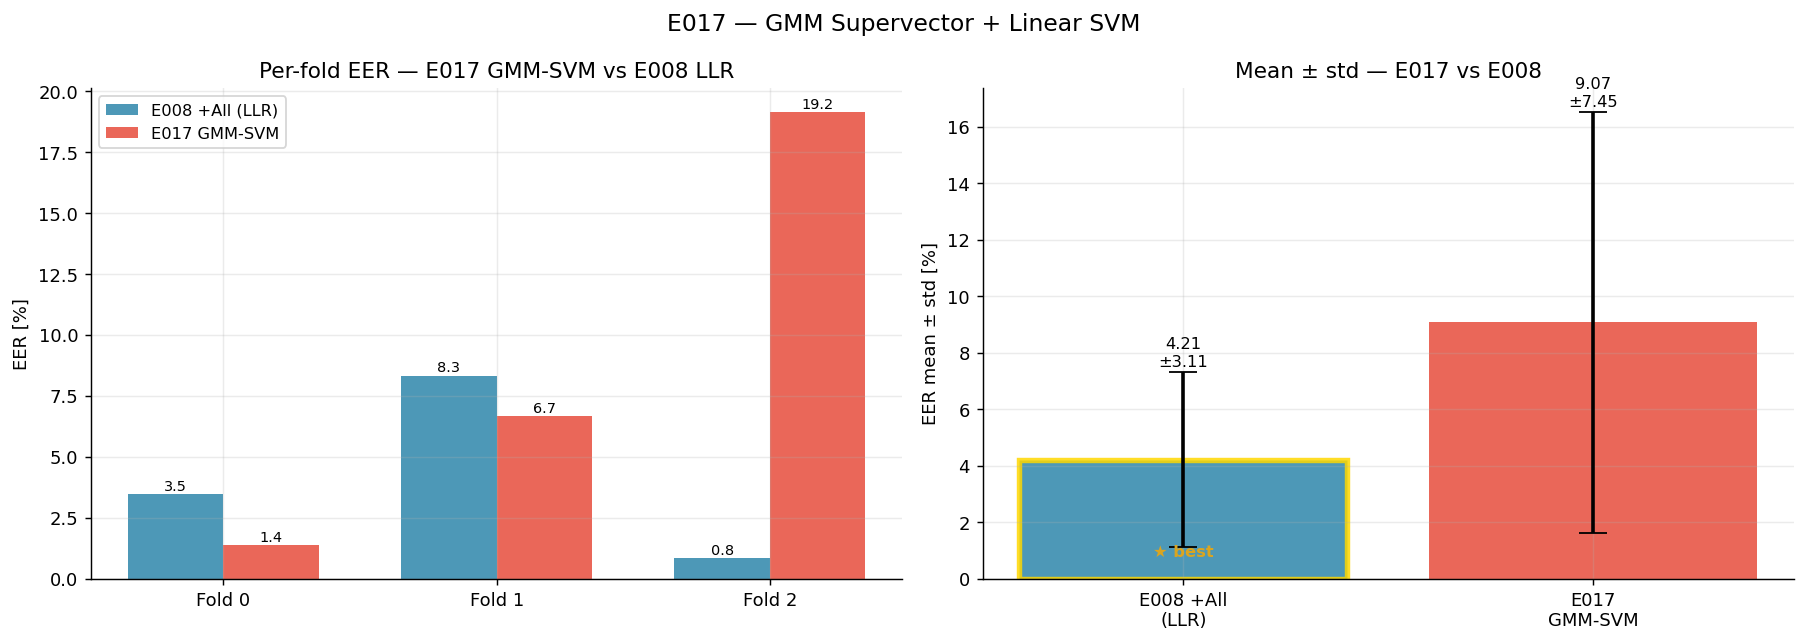

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-fold grouped bars — E017 vs E008
ax = axes[0]
x = np.arange(3)
width = 0.35
e008_vals = [E008["f0"], E008["f1"], E008["f2"]]

bars_e008 = ax.bar(x - width/2, e008_vals, width,
                   label="E008 +All (LLR)", color=COLORS["nontarget"], alpha=0.85)
bars_e017 = ax.bar(x + width/2, eers, width,
                   label="E017 GMM-SVM", color=COLORS["target"], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(["Fold 0", "Fold 1", "Fold 2"])
ax.set_ylabel("EER [%]")
ax.set_title("Per-fold EER — E017 GMM-SVM vs E008 LLR")
ax.legend(fontsize=9)
for bar, v in zip(bars_e008, e008_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.15, f"{v:.1f}", ha="center", fontsize=8)
for bar, v in zip(bars_e017, eers):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.15, f"{v:.1f}", ha="center", fontsize=8)

# Mean ± std comparison
ax = axes[1]
configs  = ["E008 +All\n(LLR)", "E017\nGMM-SVM"]
means_   = [E008["mean"], mean_e]
stds_    = [E008["std"],  std_e]
colors_  = [COLORS["nontarget"], COLORS["target"]]
bars_ = ax.bar(range(2), means_, color=colors_, alpha=0.85,
               yerr=stds_, capsize=8, error_kw=dict(elinewidth=2))
for bar, m, s in zip(bars_, means_, stds_):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.2,
            f"{m:.2f}\n±{s:.2f}", ha="center", fontsize=9)
best_idx_ = int(np.argmin(means_))
bars_[best_idx_].set_edgecolor("gold")
bars_[best_idx_].set_linewidth(3)
ax.annotate("★ best", xy=(best_idx_, means_[best_idx_] - stds_[best_idx_] - 0.3),
            ha="center", fontsize=9, color="goldenrod", fontweight="bold")
ax.set_xticks(range(2))
ax.set_xticklabels(configs, fontsize=10)
ax.set_ylabel("EER mean ± std [%]")
ax.set_title("Mean ± std — E017 vs E008")

plt.suptitle("E017 — GMM Supervector + Linear SVM", fontsize=13)
plt.tight_layout()
plt.show()

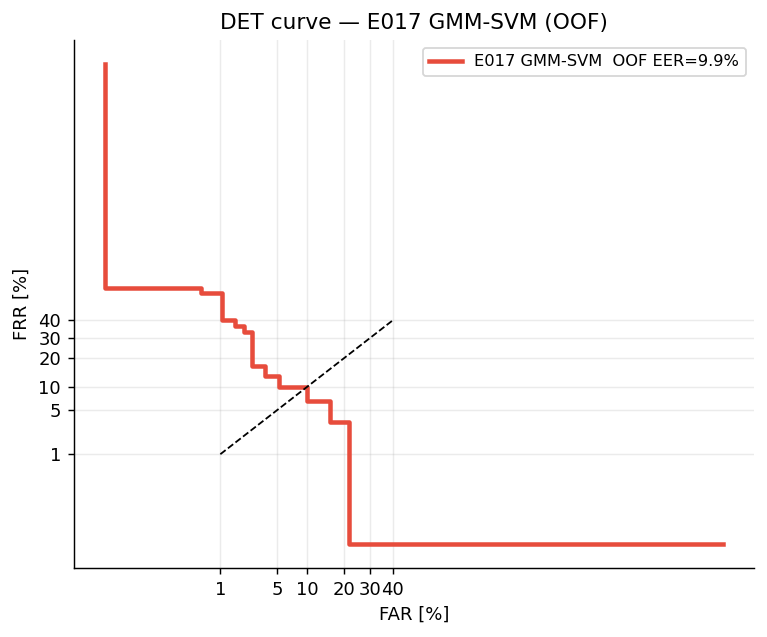

In [7]:
# DET curve for E017
ticks = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]
tick_pos    = [scipy_norm.ppf(t) for t in ticks]
tick_labels = [f"{int(t*100)}" for t in ticks]

fig, ax = plt.subplots(figsize=(6, 5))

for label_, oof_, color_, lw_ in [
    ("E008 +All (LLR)", None, COLORS["nontarget"], 1.5),
    ("E017 GMM-SVM",    oof_scores, COLORS["target"],    2.5),
]:
    if oof_ is None:
        continue  # E008 OOF not available here; plot E017 only
    valid_ = ~np.isnan(oof_)
    fpr_, tpr_, _ = roc_curve(y_all[valid_], oof_[valid_])
    far_c = np.clip(fpr_, 1e-4, 1-1e-4)
    frr_c = np.clip(1-tpr_, 1e-4, 1-1e-4)
    eer_c, _ = compute_eer(oof_[valid_ & (y_all==1)], oof_[valid_ & (y_all==0)])
    ax.plot(scipy_norm.ppf(far_c), scipy_norm.ppf(frr_c),
            color=color_, lw=lw_,
            label=f"{label_}  OOF EER={eer_c*100:.1f}%")

ax.plot(tick_pos, tick_pos, "k--", lw=1)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_labels)
ax.set_xlabel("FAR [%]")
ax.set_ylabel("FRR [%]")
ax.set_title("DET curve — E017 GMM-SVM (OOF)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

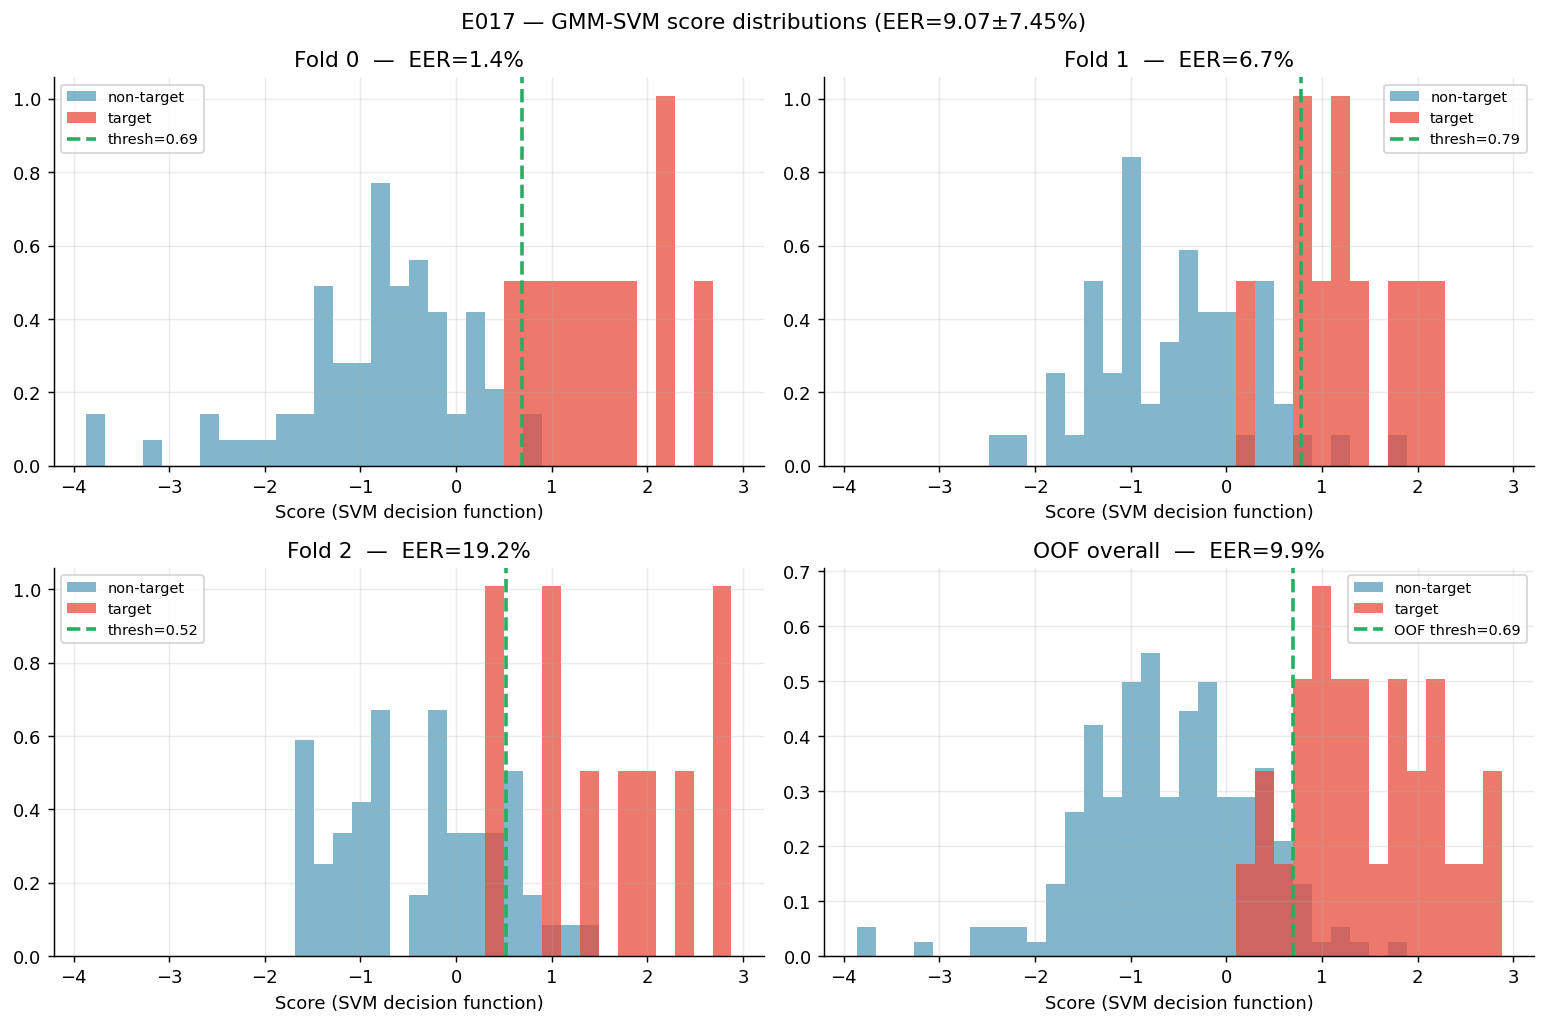


Final summary:
  E008 +All (LLR): EER = 4.21 ± 3.11%
  E017 GMM-SVM:    EER = 9.07 ± 7.45%
  Delta: +4.86%


In [8]:
# Score distributions per fold + OOF
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

bin_edges = np.linspace(np.nanmin(oof_scores), np.nanmax(oof_scores), 35)

fold_data = []
for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
    fold_data.append({
        "scores": oof_scores[val_idx],
        "labels": manifest.loc[val_idx, "label"].to_numpy(),
    })

for i, (ax, fdata) in enumerate(zip(axes[:3], fold_data)):
    s, l = fdata["scores"], fdata["labels"]
    eer_f, thr_f = compute_eer(s[l==1], s[l==0])
    ax.hist(s[l==0], bins=bin_edges, alpha=0.6, color=COLORS["nontarget"], label="non-target", density=True)
    ax.hist(s[l==1], bins=bin_edges, alpha=0.75, color=COLORS["target"], label="target", density=True)
    ax.axvline(thr_f, color=COLORS["green"], ls="--", lw=2, label=f"thresh={thr_f:.2f}")
    ax.set_title(f"Fold {i}  —  EER={eer_f*100:.1f}%")
    ax.set_xlabel("Score (SVM decision function)")
    ax.legend(fontsize=8)

ax = axes[3]
ax.hist(oof_scores[y_all==0], bins=bin_edges, alpha=0.6, color=COLORS["nontarget"], label="non-target", density=True)
ax.hist(oof_scores[y_all==1], bins=bin_edges, alpha=0.75, color=COLORS["target"], label="target", density=True)
ax.axvline(thr, color=COLORS["green"], ls="--", lw=2, label=f"OOF thresh={thr:.2f}")
ax.set_title(f"OOF overall  —  EER={eer_oof*100:.1f}%")
ax.set_xlabel("Score (SVM decision function)")
ax.legend(fontsize=8)

plt.suptitle(f"E017 — GMM-SVM score distributions (EER={mean_e:.2f}±{std_e:.2f}%)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nFinal summary:")
print(f"  E008 +All (LLR): EER = {E008['mean']:.2f} ± {E008['std']:.2f}%")
print(f"  E017 GMM-SVM:    EER = {mean_e:.2f} ± {std_e:.2f}%")
print(f"  Delta: {sign}{delta:.2f}%")